№2 **(3 балла)**<br/>
Выполните задания из файла https://cloud.mail.ru/public/JAFw/L4EF7Eyy7. <br/>
Данные скачайте отсюда https://cloud.mail.ru/public/bevg/K948tN4hd<br/>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sb
from scipy.stats import norm
from scipy import stats
from pandas import DataFrame

1) Данные
Данные (house_train.csv) представляют собой набор данных о ценах на
жилье. Подготовьте информацию о датасете:

In [6]:
pd.set_option('display.max_columns', 100)
df = pd.read_csv('house_train.csv')
df.drop('Id', axis=1, inplace=True)
df.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Unnamed: 81
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,NaN
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,NaN
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,NaN
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,NaN
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,NaN


Приведите описание датасета:<br/>
- Сколько данных в датасете?<br/>
– Сколько параметров? Выведите список всех параметров.<br/>
– Есть ли категориальные признаки? Перечислите / выведите их.<br/>
– Выведите первые пять строчек DataFrame.<br/>
– По умолчанию pandas, ради экономии времени, указывает приблизительные
сведения об использовании памяти объектом DataFrame. Если нас интересуют
точные сведения, то нужно установить параметр memory_usage в значение
'deep':


In [5]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

2) Просмотреть основную информацию по датасету можно, выполнив
инструкции (сейчас выполнять не нужно, выполним ниже)


In [7]:
df.columns #Просмотр имен столбцов функций
df.shape #Просмотр количества строк и столбцов
df.describe() #Просмотр основной статистики

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Unnamed: 81
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,0.0
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,NaN
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,NaN
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,NaN
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,NaN
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,NaN
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,NaN
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,NaN


С помощью метода describe() выведите описательную статистику
числовых данных:


In [8]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Unnamed: 81
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,0.0
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,NaN
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,NaN
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,NaN
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,NaN
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,NaN
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,NaN
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,NaN


А что будет, если выполнить такую инструкцию: 
df.describe().T 

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


– получим статистику отдельного показателя, например, "SalePrice":
df['SalePrice'].describe()


In [10]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Укажите:<br/> 
а) чему равно среднее значение?<br/>
б) чему равно стандартное отклонение?

In [ ]:
"""
a) 180921.195890
b) 79442.502883
"""

3) Проверьте, есть ли пропуски и повторы в данных.
Пропущенные и неопределённые значения выявляет метод isna(), а суммарное
количество таких значений – метод sum().
Вызов обоих методов можно записать в одну строку, разделив их точкой. Python
сначала вызовет метод isna(), а затем результаты его работы передаст методу
sum():


In [11]:
print(df.isna().sum())

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Unnamed: 81      1460
Length: 81, dtype: int64


– Количество пустых значений в наборе данных можно сохранить. Результат
сохраним в переменной na_number:


In [12]:
na_number=(df.isna().sum())
print(na_number)

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Unnamed: 81      1460
Length: 81, dtype: int64


Повторяющиеся строки – дубликаты – выявляются методом
duplicated() и подсчитываются тем же sum(). Если возвращаются нули, то
данные пригодны для исследования:

In [13]:
print(df.duplicated().sum()) 

0


– Количество дубликатов в наборе данных можно сохранить, например, в
переменной duplicated_number:

In [ ]:
duplicated_number=df.duplicated().sum()
print(duplicated_number)

4) Получите список названий столбцов, запросив атрибут columns.

In [ ]:
print(df.columns)

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

5) Анализ пропущенных значений и удаление<br/>
а) Выясним, в каких параметрах отсутствует статистика (данные):

In [ ]:
na_count = df.isnull().sum().sort_values(ascending=False)
# Вычисляем, сколько пропущенных значений в параметрах
na_rate = na_count / len(df) 
# Вычисляем частоту или вероятность, с которой пропущенное значение
# встречается в каждом параметре. 
# Если вероятность большая (>0.5), столбцы-параметры можно смело удалять).
# формируем массив для печати
na_data = pd.concat([na_count,
na_rate],axis=1,keys=['count','ratio'])
print(na_data)

б) Вообще говоря, если количество отсутствующих данных для
определенного признака достигает более 15%, то этот признак следует удалить, и
считается, что такого признака нет в наборе данных – то есть мы не будем
пытаться заполнить отсутствующие значения этих признаков).
– Проследим за количеством оставшихся столбцов. Зафиксируем первоначальное
количество столбцов с помощью функции: 

In [15]:
df.shape

(1460, 81)

Удалите столбцы с максимальным количеством отсутствующих данных:
'PoolQC', 'MiscFeature' и 'Alley'. 

In [ ]:
# df = df.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1)

или лучше создайте новый файл и выведите столбцы

In [16]:
df_new=df.drop(['PoolQC', 'MiscFeature', 'Alley'], axis=1)
print(df_new.isna().sum())

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Unnamed: 81      1460
Length: 78, dtype: int64


– Выведем отдельно количество оставшихся столбцов:

In [17]:
df_new.shape

(1460, 78)

В оставшихся переменных с пропущенными значениями несколько функций GarageX. 'GarageQual' и 'GarageCond' имеют одинаковое количество
пропущенных значений. На основании этого делаем вывод, что они могут представлять один и тот же набор наблюдений, поэтому удалим эти функции. Ту же
операцию можно выполнить для Fence – изгородь – 1179 нулей.

In [18]:
df_new = df_new.drop(['GarageQual', 'GarageCond', 'Fence'],
axis=1)
print(df_new.isna().sum()) 

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Unnamed: 81      1460
Length: 75, dtype: int64


Что касается MasVnrArea и MasVnrType, в соответствии с их буквальным значением, мы думаем, что они не важны, и у них есть сильная корреляция
(как мы увидим дальше) с YearBuilt и GeneralQual. Таким образом, мы не
потеряем никакой информации, если удалим эти две функции.


In [19]:
df_new=df_new.drop(['MasVnrArea', 'MasVnrType'], axis=1)
print(df_new.isna().sum())

MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
                 ... 
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Unnamed: 81      1460
Length: 73, dtype: int64


– Выведем отдельно количество оставшихся столбцов:

In [ ]:
df_new.shape # Размер данных после обработки пропущенного значения

(1460, 73)

В общем, мы удалили почти все переменные с пропущенными значениями.<br/>
6. Однофакторный анализ данных<br/>
- Переименуем опять файл:

In [22]:
df = df_new

- Проверим размер данных:

In [ ]:
df.shape

(1460, 73)

- Считаем заново исходный файл с данными: 

In [24]:
df = pd.read_csv('house_train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Unnamed: 81
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,NaN
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,NaN
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,NaN
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,NaN
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,NaN


6.1. Гистограмма<br/>
Построим гистограмму параметра SalePrice в библиотеке seaborn:

C:\Users\011ko\AppData\Local\Temp\ipykernel_23652\992221721.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df['SalePrice'])


<Axes: xlabel='SalePrice', ylabel='Density'>

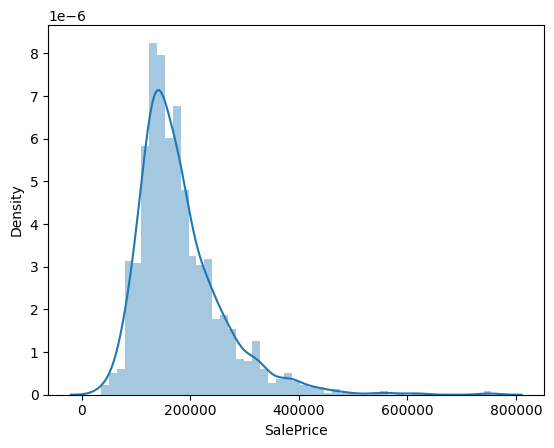

In [27]:
sb.distplot(df['SalePrice'])

По рисунку: цена дома подчиняется нормальному распределению?

In [ ]:
"""
НЕТ 
Распределение ассиметрично и имеет длинный хвост вправо (правостороння / положительная ассиметрия)
"""

Можем рассчитать его асимметрию и эксцесс:

In [28]:
print("Skewness: %f" % df['SalePrice'].skew())
print("Kurtosis: %f" % df['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


Задание: Постройте гистограмму параметра SalePrice всех домов c заголовком
'Histogram of Sale Price', заголовок оси х – 'price', заголовок оси у
– 'count'.


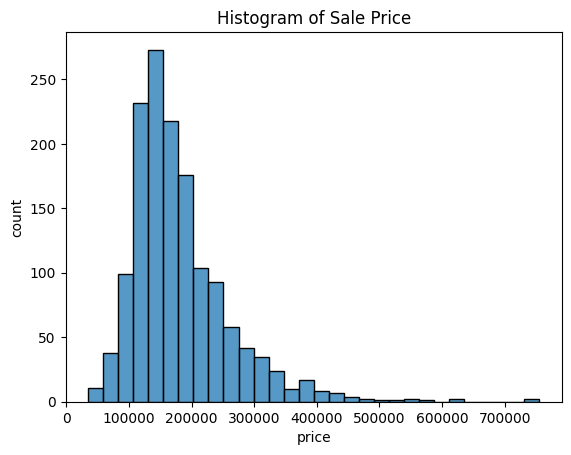

In [29]:
sb.histplot(data=df, x="SalePrice", bins=30, edgecolor="black", linewidth=1)
plt.title("Histogram of Sale Price")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

6.2. Boxplot

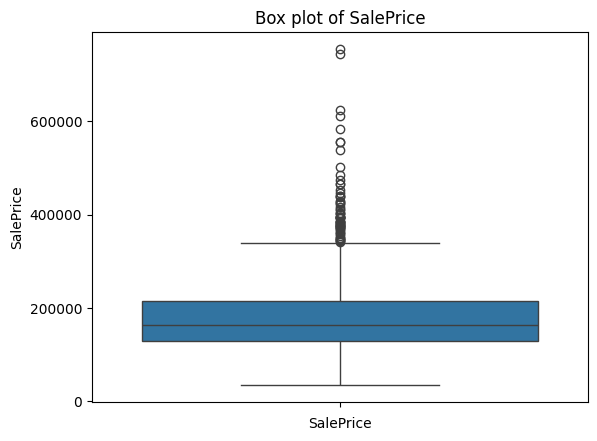

In [30]:
ax = sb.boxplot(data=df, y="SalePrice", )
ax.set_xlabel("SalePrice")
ax.set_title("Box plot of SalePrice")
ax.set_yticks([0, 200000, 400000, 600000])

plt.show()

а) Для построения Boxplot и гистограмм цены дома сгруппируем данные с
кондиционером (name = 'With air conditioning') и без кондиционера
(name = 'No air conditioning'); для Boxplot title = "Boxplot of
Sale Price by air conditioning". Результат:

In [ ]:
import numpy as np

df["AC_group"] = np.where(df["CentralAir"].eq("Y"),
                          "With air conditioning",
                          "No air conditioning")

ax = sb.boxplot(
    data=df,
    x="AC_group",
    y="SalePrice"
)

ax.set_title("Boxplot of Sale Price by air conditioning")
ax.set_xlabel("")
ax.set_ylabel("SalePrice")
ax.set_yticks([0, 200000, 400000, 600000])
plt.legend()
plt.show()

б) Для гистограммы – заголовок title='Histogram of House Sale
Price for both with and with no Central air conditioning'


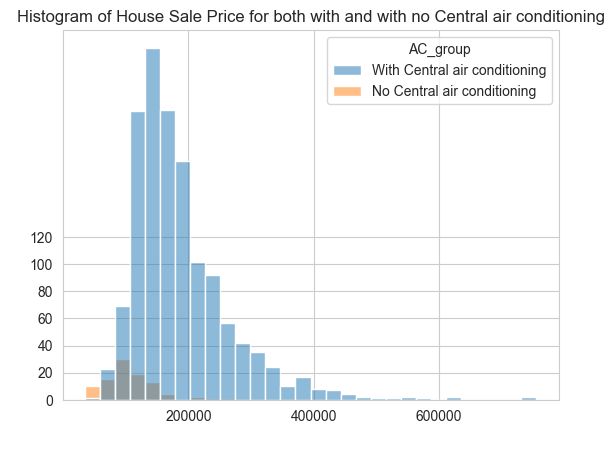

In [31]:
# подписи групп
df["AC_group"] = np.where(
    df["CentralAir"].eq("Y"),
    "With Central air conditioning",
    "No Central air conditioning"
)

# с наложением двух групп
sb.set_style("whitegrid")
ax = sb.histplot(
    data=df,
    x="SalePrice",
    hue="AC_group",
    bins=30,
    stat="count",
    common_bins=True,
    multiple="layer"
)

ax.set_title("Histogram of House Sale Price for both with and with no Central air conditioning")
ax.set_xlabel(" ")
ax.set_ylabel(" ")
ax.set_xticks([200000, 400000, 600000])
ax.set_yticks([0, 20, 40, 60, 80, 100, 120])
plt.show()

в) Выведем описательную статистику 'CentralAir' и 'SalePrice' с
помощью инструкции:

In [32]:
df.groupby('CentralAir')['SalePrice'].describe()

,count,mean,std,min,25%,50%,75%,max
CentralAir,,,,,,,,
N,95.0,105264.073684,40671.273961,34900.0,82000.0,98000.0,128500.0,265979.0
Y,1365.0,186186.709890,78805.206820,52000.0,134800.0,168000.0,219210.0,755000.0


г) Постройте Boxplot и гистограмму цены продажи домов (параметр
'SalePrice'), сгруппированные по размеру гаража (параметр
'GarageCars'): title = "Boxplot of Sale Price by garage
size".
Используйте при группировке name = 'no garage' и name = '1-
car garage' – если гараж для одной машины; name = '2-car garage' –
если гараж для двух машин; name = '3-car garage' – если гараж для трех
машин; name = '4-car garage' – если гараж для четырех машин.

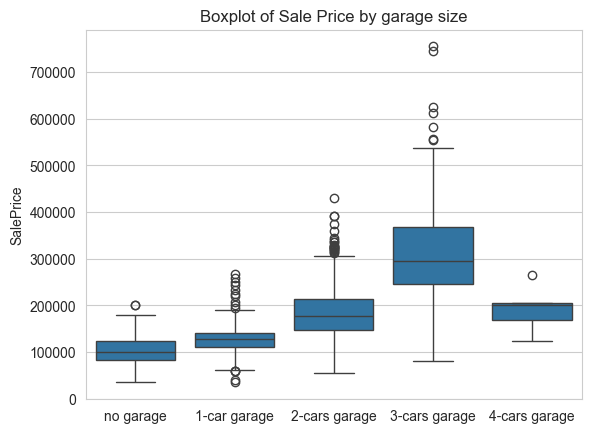

In [33]:
garage_map = {
    0: "no garage",
    1: "1-car garage",
    2: "2-cars garage",
    3: "3-cars garage",
    4: "4-cars garage",
}
g = df["GarageCars"].astype("Int64")

df["Garage_group"] = g.map(garage_map)
order = ["no garage", "1-car garage", "2-cars garage", "3-cars garage", "4-cars garage"]

ax = sb.boxplot(
    data=df,
    x="Garage_group",
    y="SalePrice",
    order=order
)

ax.set_title("Boxplot of Sale Price by garage size")
ax.set_xlabel("")
ax.set_ylabel("SalePrice")
plt.show()

Судить о средней цене дома можно по черте внутри каждого блока.
**Прокомментируйте среднюю цену дома в зависимости от размеров гаража.**

In [ ]:
"""
Можно заметить, что дома без гаража стоят дешевле, чем дома, оборудованные гаражом. 
С увеличением вместимости гаража средняя цена дома растёт, однако для гаражей на четыре 
машины она заметно снижается. Вероятно, это связано с низким спросом на столь 
большие гаражи — они нужны немногим, поэтому и стоимость домов с ними ниже, чем с трёхместными.
"""

Постройте:
д) Гистограмму цены продажи дома без гаража

title='Histogram of Sale Price of houses with no garage'

е) Гистограмму цены продажи дома с гаражом на 1 машину

title='Histogram of Sale Price of houses with 1-car garage'

ё) Гистограмму цены продажи дома с гаражом на 2 машины

title='Histogram of Sale Price of houses with 2-car garage')

ж) Гистограмму цены продажи дома с гаражом на 3 машины

title='Histogram of Sale Price of houses with 3-car garage'

з) Гистограмму цены продажи дома с гаражом на 4 машины

title='Histogram of Sale Price of houses with 4-car garage'

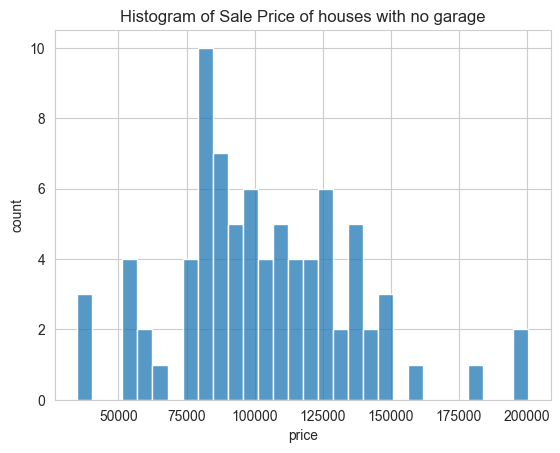

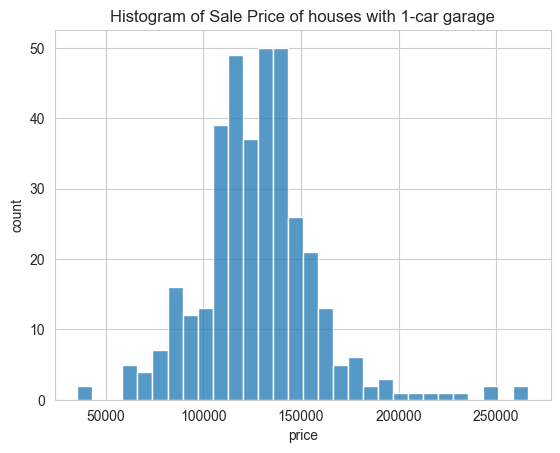

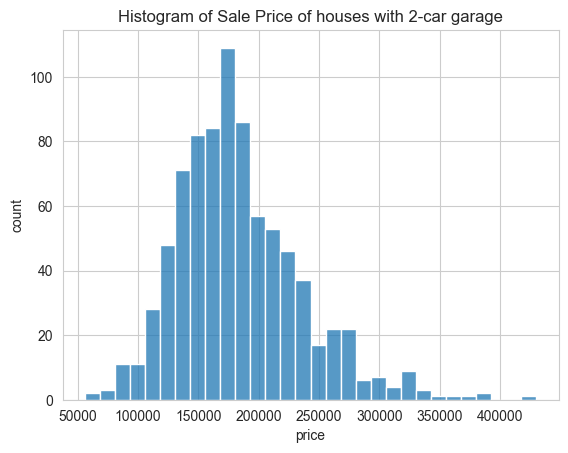

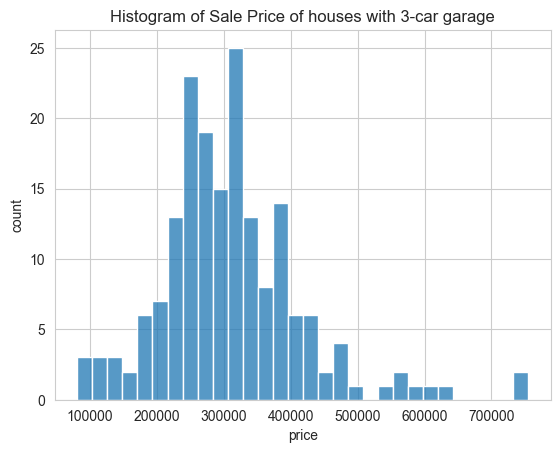

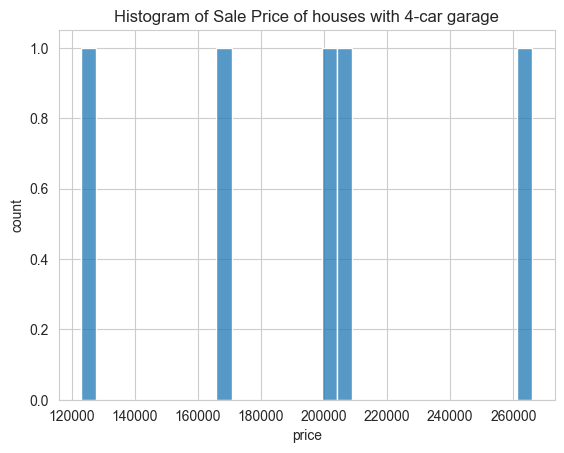

In [34]:
def plot_hist_for_garage(cars, title):
    d = df[df["GarageCars"] == cars]  # фильтр по количеству мест в гараже [web:300]
    ax = sb.histplot(data=d, x="SalePrice", bins=30, stat="count")  # [web:143]
    ax.set_title(title)
    ax.set_xlabel("price")
    ax.set_ylabel("count")
    plt.show()

plot_hist_for_garage(0, "Histogram of Sale Price of houses with no garage")
plot_hist_for_garage(1, "Histogram of Sale Price of houses with 1-car garage")
plot_hist_for_garage(2, "Histogram of Sale Price of houses with 2-car garage")
plot_hist_for_garage(3, "Histogram of Sale Price of houses with 3-car garage")
plot_hist_for_garage(4, "Histogram of Sale Price of houses with 4-car garage")


6.4. Таблица частот
Значение частоты говорит о том, как часто какая-то величина встречается в
выборке.
Общую таблицу частот параметров можно получить, исполнив программный код:

In [35]:
x = df.OverallQual.value_counts()
x/x.sum()

OverallQual
5     0.271918
6     0.256164
7     0.218493
8     0.115068
4     0.079452
9     0.029452
3     0.013699
10    0.012329
2     0.002055
1     0.001370
Name: count, dtype: float64

а) Таблица частот размеров гаража

In [36]:
x = df.GarageCars.value_counts()
x/x.sum()

GarageCars
2    0.564384
1    0.252740
3    0.123973
0    0.055479
4    0.003425
Name: count, dtype: float64

Гаражи какого размера наиболее распространены?

In [ ]:
"""2 (гараж на 2 места)"""

б) Таблица частот центрального кондиционирования

In [ ]:
x = df.CentralAir.value_counts()
x/x.sum()


б) Таблица частот центрального кондиционирования


In [37]:
x = df.CentralAir.value_counts()
x/x.sum()

CentralAir
Y    0.934932
N    0.065068
Name: count, dtype: float64

6.5. Числовые характеристики параметров

Быстрый способ получить набор числовых сводок для количественной
переменной – это использовать метод description.

In [38]:
df.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

– Рассчитайте долю домов с продажной ценой между 25-м процентилем (129975)
и 75-м процентилем (214000).

In [39]:
print(
    "The proportion of the houses with prices between 25th percentile and 75th percentile: ",
    np.mean((df.SalePrice >= 129975) & (df.SalePrice <= 214000))
)

The proportion of the houses with prices between 25th percentile and 75th percentile:  0.5020547945205479


– Рассчитайте долю домов с общей площадью в квадратных футах от 25-го
процентиля (795,75) до 75-го процентиля (1298,25).

In [40]:
print(
    'The proportion of house with total square feet of basement area between 25th percentile and 75th percentile:',
    np.mean((df.TotalBsmtSF >= 795.75) & (df.TotalBsmtSF <= 1298.25)))

The proportion of house with total square feet of basement area between 25th percentile and 75th percentile: 0.5


– Наконец, мы рассчитаем долю домов на основе любых условий. Поскольку
некоторые дома соответствуют обоим критериям, приведенная ниже пропорция
меньше суммы двух пропорций, рассчитанных выше.

In [41]:
a = (df.SalePrice >= 129975) & (df.SalePrice <= 214000)
b = (df.TotalBsmtSF >= 795.75) & (df.TotalBsmtSF <=
1298.25)
print(np.mean(a | b))

0.7143835616438357


– Рассчитать цену продажи интерквартильного размаха IQR для домов без
кондиционера. Англоязычная аббревиатура IQR – интерквартильный размах –
число, которое показывает разброс средней половины (т.е. средние 50%) набора
данных и помогает определить выбросы. IQR – это разница между третьим
квартилем (Q3) и первым(Q1).

In [45]:
q75, q25 = np.percentile(df.loc[df['CentralAir']=='N']['SalePrice'], [75,25])
iqr = q75 - q25
print('Sale price IQR for houses with no air conditioning:', iqr)

Sale price IQR for houses with no air conditioning: 46500.0


– Рассчитать цену продажи IQR для домов с кондиционером

In [43]:
q75, q25 = np.percentile(df.loc[df['CentralAir']=='Y']['SalePrice'], [75,25])
iqr = q75 - q25
print('Sale price IQR for houses with air conditioning: ', iqr)


Sale price IQR for houses with air conditioning:  84410.0


– Создадим новый столбец HouseAge (YearBuilt), затем разделим данные на части
HouseAge и построим параллельные боксовые диаграммы цены продажи внутри
каждой страты.

<Axes: xlabel='AgeGrp', ylabel='SalePrice'>

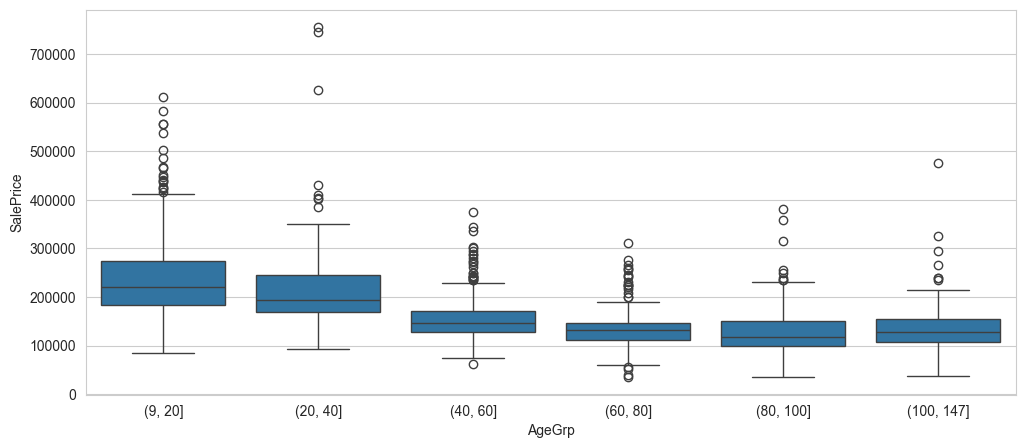

In [44]:
df['HouseAge'] = 2019 - df['YearBuilt']
df["AgeGrp"] = pd.cut(df.HouseAge, [9, 20, 40, 60, 80, 100, 147]) # Create age strata based on these cut points
plt.figure(figsize=(12, 5))
sb.boxplot(x="AgeGrp", y="SalePrice", data=df)

Вопрос: Сравните возраст дома и среднюю цену на него. Какая наблюдается
закономерность?

In [ ]:
"""
Чем "моложе" дом, тем выше цена
"""

– Ранее мы узнали, что цены на жилье, как правило, различаются по наличию или
отсутствию кондиционеров в них. Из построенных по приведенному ниже коду
графиков сделайте вывод: какие по возрасту дома более оснащены
кондиционерами.

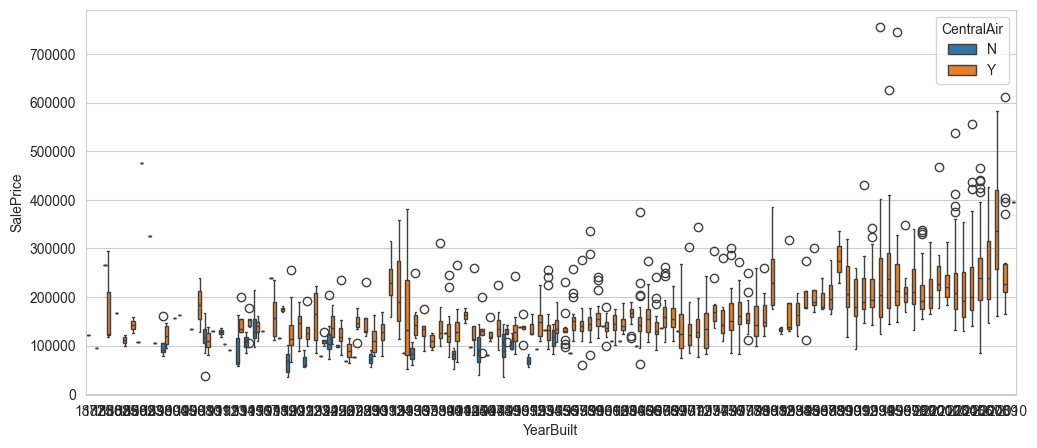

In [46]:
plt.figure(figsize=(12, 5))
sb.boxplot(x="YearBuilt", y="SalePrice", hue="CentralAir", data=df)
plt.show()

In [ ]:
"""
Более оснащены кондиционерами более новые дома
"""

– Теперь мы сгруппируем сначала по кондиционированию воздуха, а затем в
группе кондиционирования по возрастным группам. Каждый подход
подчеркивает различные аспекты данных.

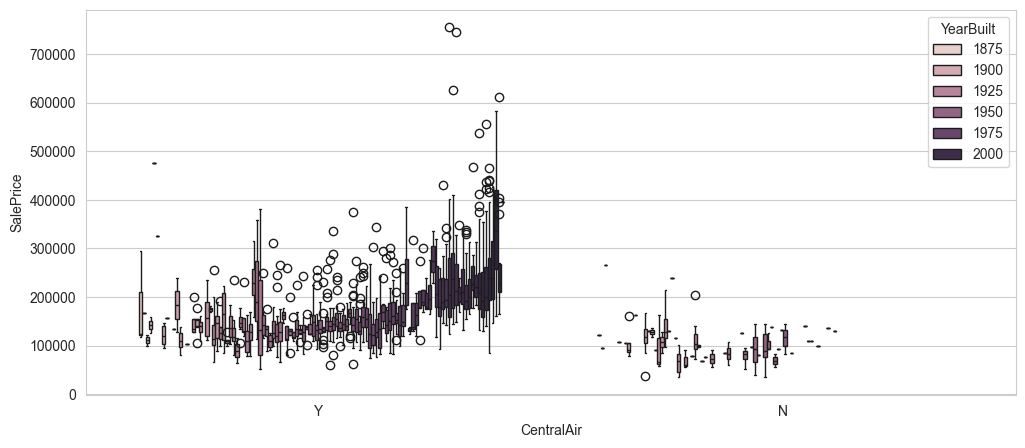

In [47]:
plt.figure(figsize=(12, 5))
sb.boxplot(x="CentralAir", y="SalePrice",
hue="YearBuilt", data=df)
plt.show()

– Мы также можем рассортировать по возрасту дома и кондиционированию
воздуха, чтобы исследовать, как тип здания зависит от обоих этих факторов
одновременно.

In [48]:
df1 = df.groupby(["YearBuilt", "CentralAir"])["BldgType"]
df1 = df1.value_counts()
df1 = df1.unstack()
df1 = df1.apply(lambda x: x/x.sum(), axis=1)
print(df1.to_string(float_format="%.3f"))

BldgType              1Fam  2fmCon  Duplex  Twnhs  TwnhsE
YearBuilt CentralAir                                     
1872      N          1.000     NaN     NaN    NaN     NaN
1875      N          1.000     NaN     NaN    NaN     NaN
1880      N          1.000     NaN     NaN    NaN     NaN
          Y          1.000     NaN     NaN    NaN     NaN
1882      Y          1.000     NaN     NaN    NaN     NaN
1885      Y          0.500   0.500     NaN    NaN     NaN
1890      Y          1.000     NaN     NaN    NaN     NaN
1892      N          1.000     NaN     NaN    NaN     NaN
          Y          1.000     NaN     NaN    NaN     NaN
1893      Y          1.000     NaN     NaN    NaN     NaN
1898      N          1.000     NaN     NaN    NaN     NaN
1900      N          0.400   0.600     NaN    NaN     NaN
          Y          0.400   0.400   0.200    NaN     NaN
1904      Y          1.000     NaN     NaN    NaN     NaN
1905      N            NaN   1.000     NaN    NaN     NaN
1906      Y   

– Построим диаграммы рассеяния, отражающие взаимосвязь между
переменными:

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

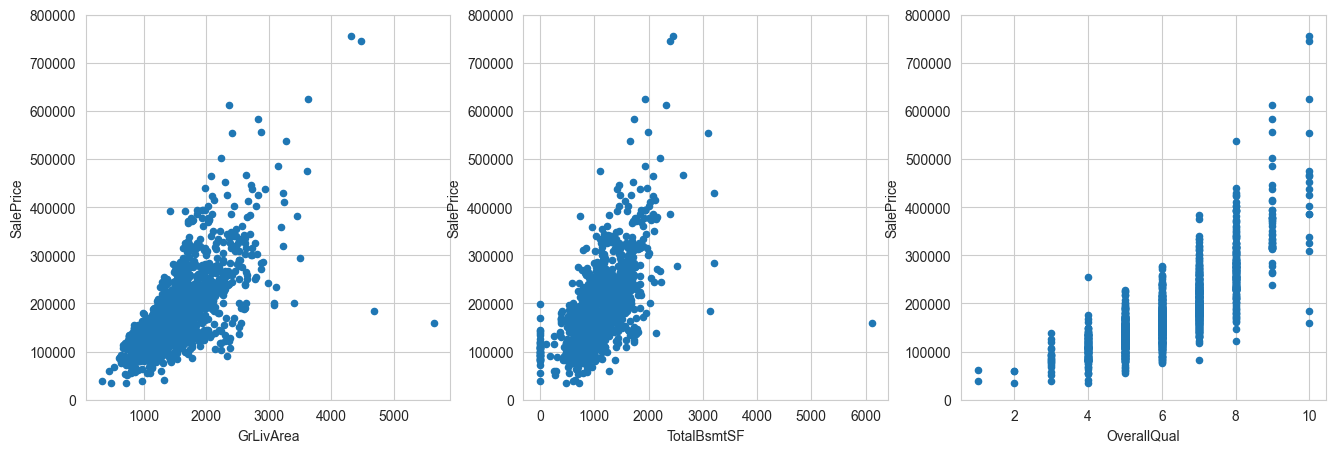

In [49]:
output,var,var1,var2 = 'SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual'
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(16,5))
df.plot.scatter(x=var,y=output,ylim=(0,800000),ax=axes[0])
df.plot.scatter(x=var1,y=output,ylim=(0,800000),ax=axes[1])
df.plot.scatter(x=var2,y=output,ylim=(0,800000),ax=axes[2])

Наблюдается ли взаимосвязь между переменными?

In [ ]:
"""
Да. На всех диаграммах видно, что при увеличении признака в среднем растёт SalePrice.
"""

– Отображение прямоугольной диаграммой

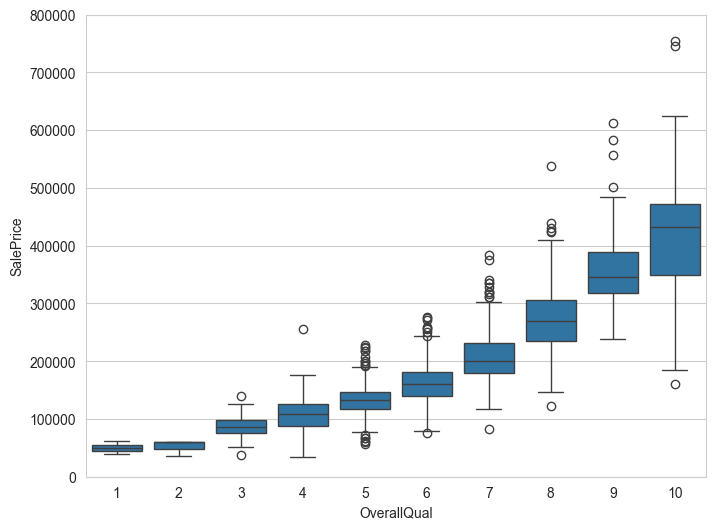

In [50]:
fig, ax = plt.subplots(figsize=(8,6))
sb.boxplot(x=var2,y=output,data=df)
ax.set_ylim(0,800000)
plt.show()

Между какими параметрами построен boxplot? Есть ли выбросы в данных?

In [ ]:
"""
Между OveralQual и SalePrice. Выбросы есть
"""

– Рассмотрите эффект, нарисованный seaborn:

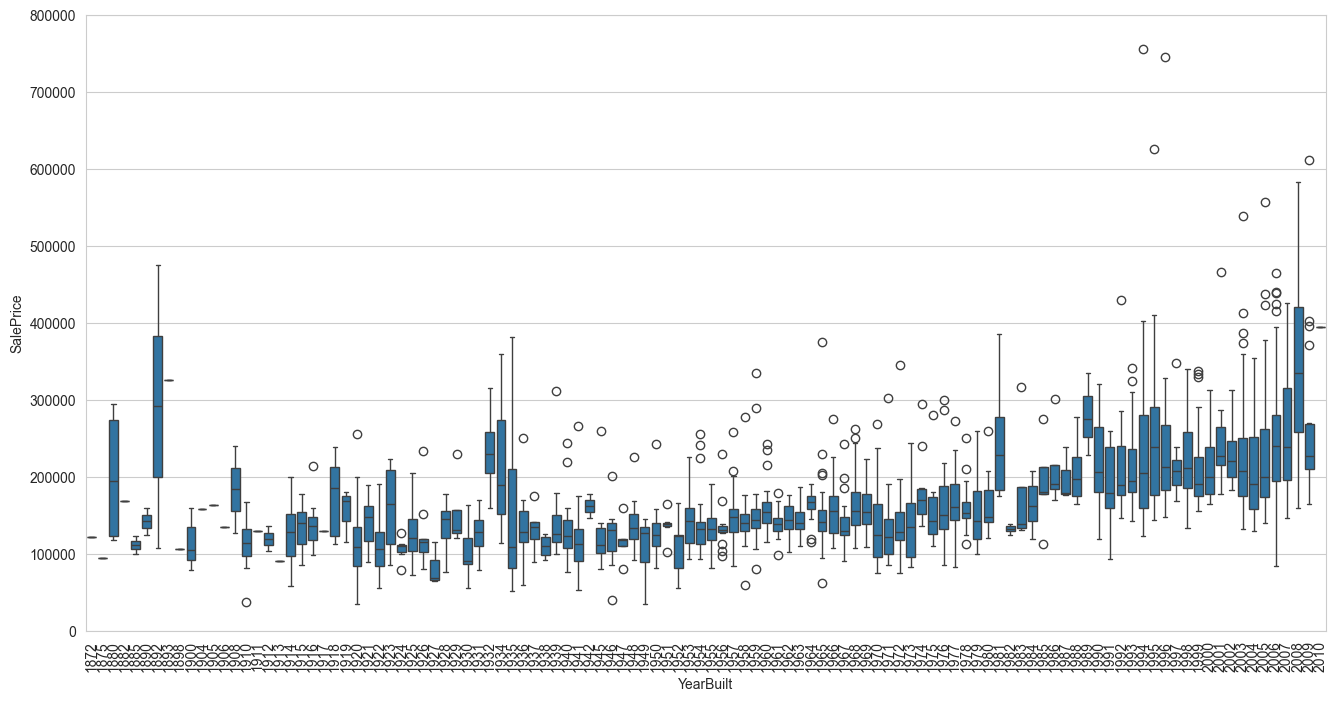

In [51]:
var3 = 'YearBuilt'
fig, ax = plt.subplots(figsize=(16,8))
sb.boxplot(x=var3,y=output,data=df)
ax.set_ylim(0,800000)
plt.xticks(rotation=90)
plt.show()

6.7. Отображение тепловой карты характеристической ковариационной матрицы


– Получите ковариационную матрицу для всех данных DataFrame и используйте
анализ тепловой карты:

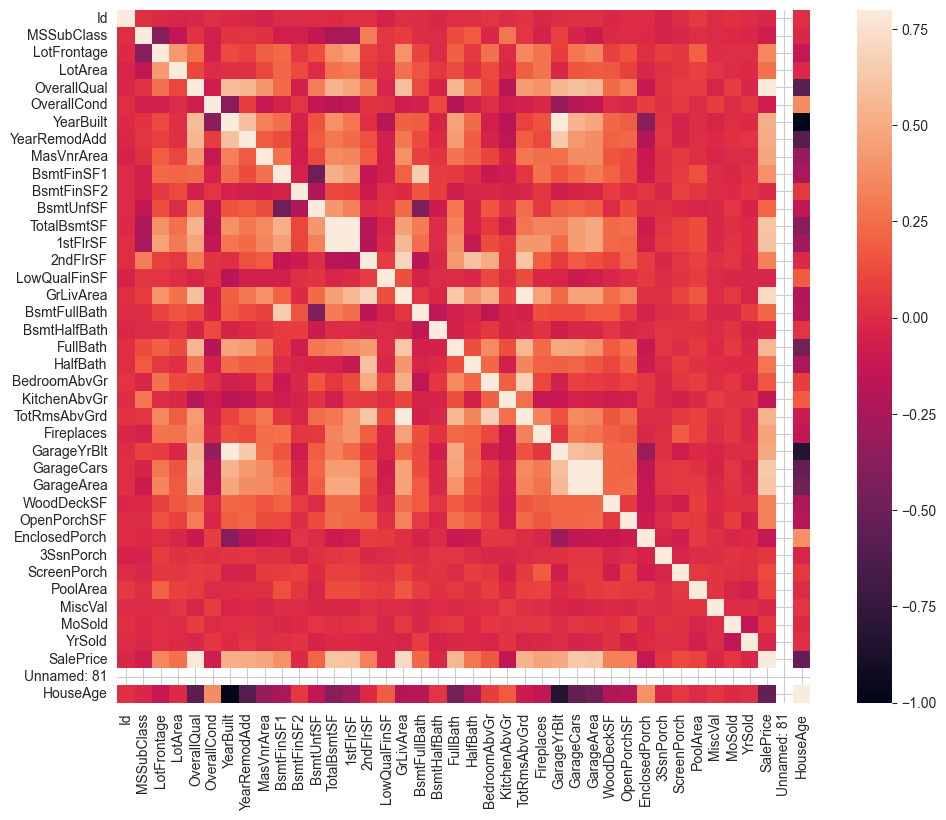

In [52]:
corrmat = df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sb.heatmap (corrmat, vmax = .8, square = True, ax = ax)
# Параметр square гарантирует, что когда corrmat -
# неквадратная матрица, общий вывод графика по-прежнему будет квадратным
plt.show()

– Давайте выберем 10 параметров с наибольшей корреляцией с SalePrice,
чтобы проанализировать корреляцию между ними.

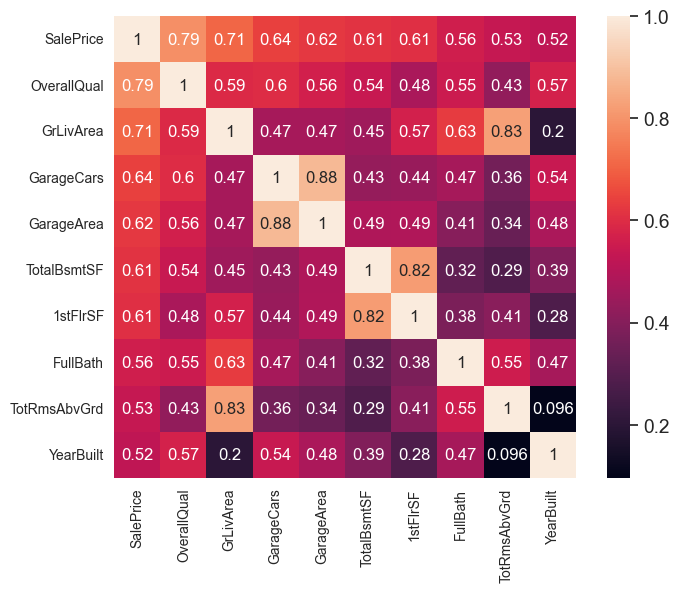

In [53]:
k = 10
top10_attr = corrmat.nlargest(k, output).index
top10_mat = corrmat.loc[top10_attr, top10_attr]
fig,ax = plt.subplots(figsize=(8,6))
sb.set(font_scale=1.25)
sb.heatmap(top10_mat, annot=True, annot_kws={'size':12},
square=True)
# Установите аннотацию для отображения чисел в маленьких ячейках и annot_kws для настройки числового формата
plt.show()


6.7. Графическая матрица, объединяющая точечные и столбчатые диаграммы

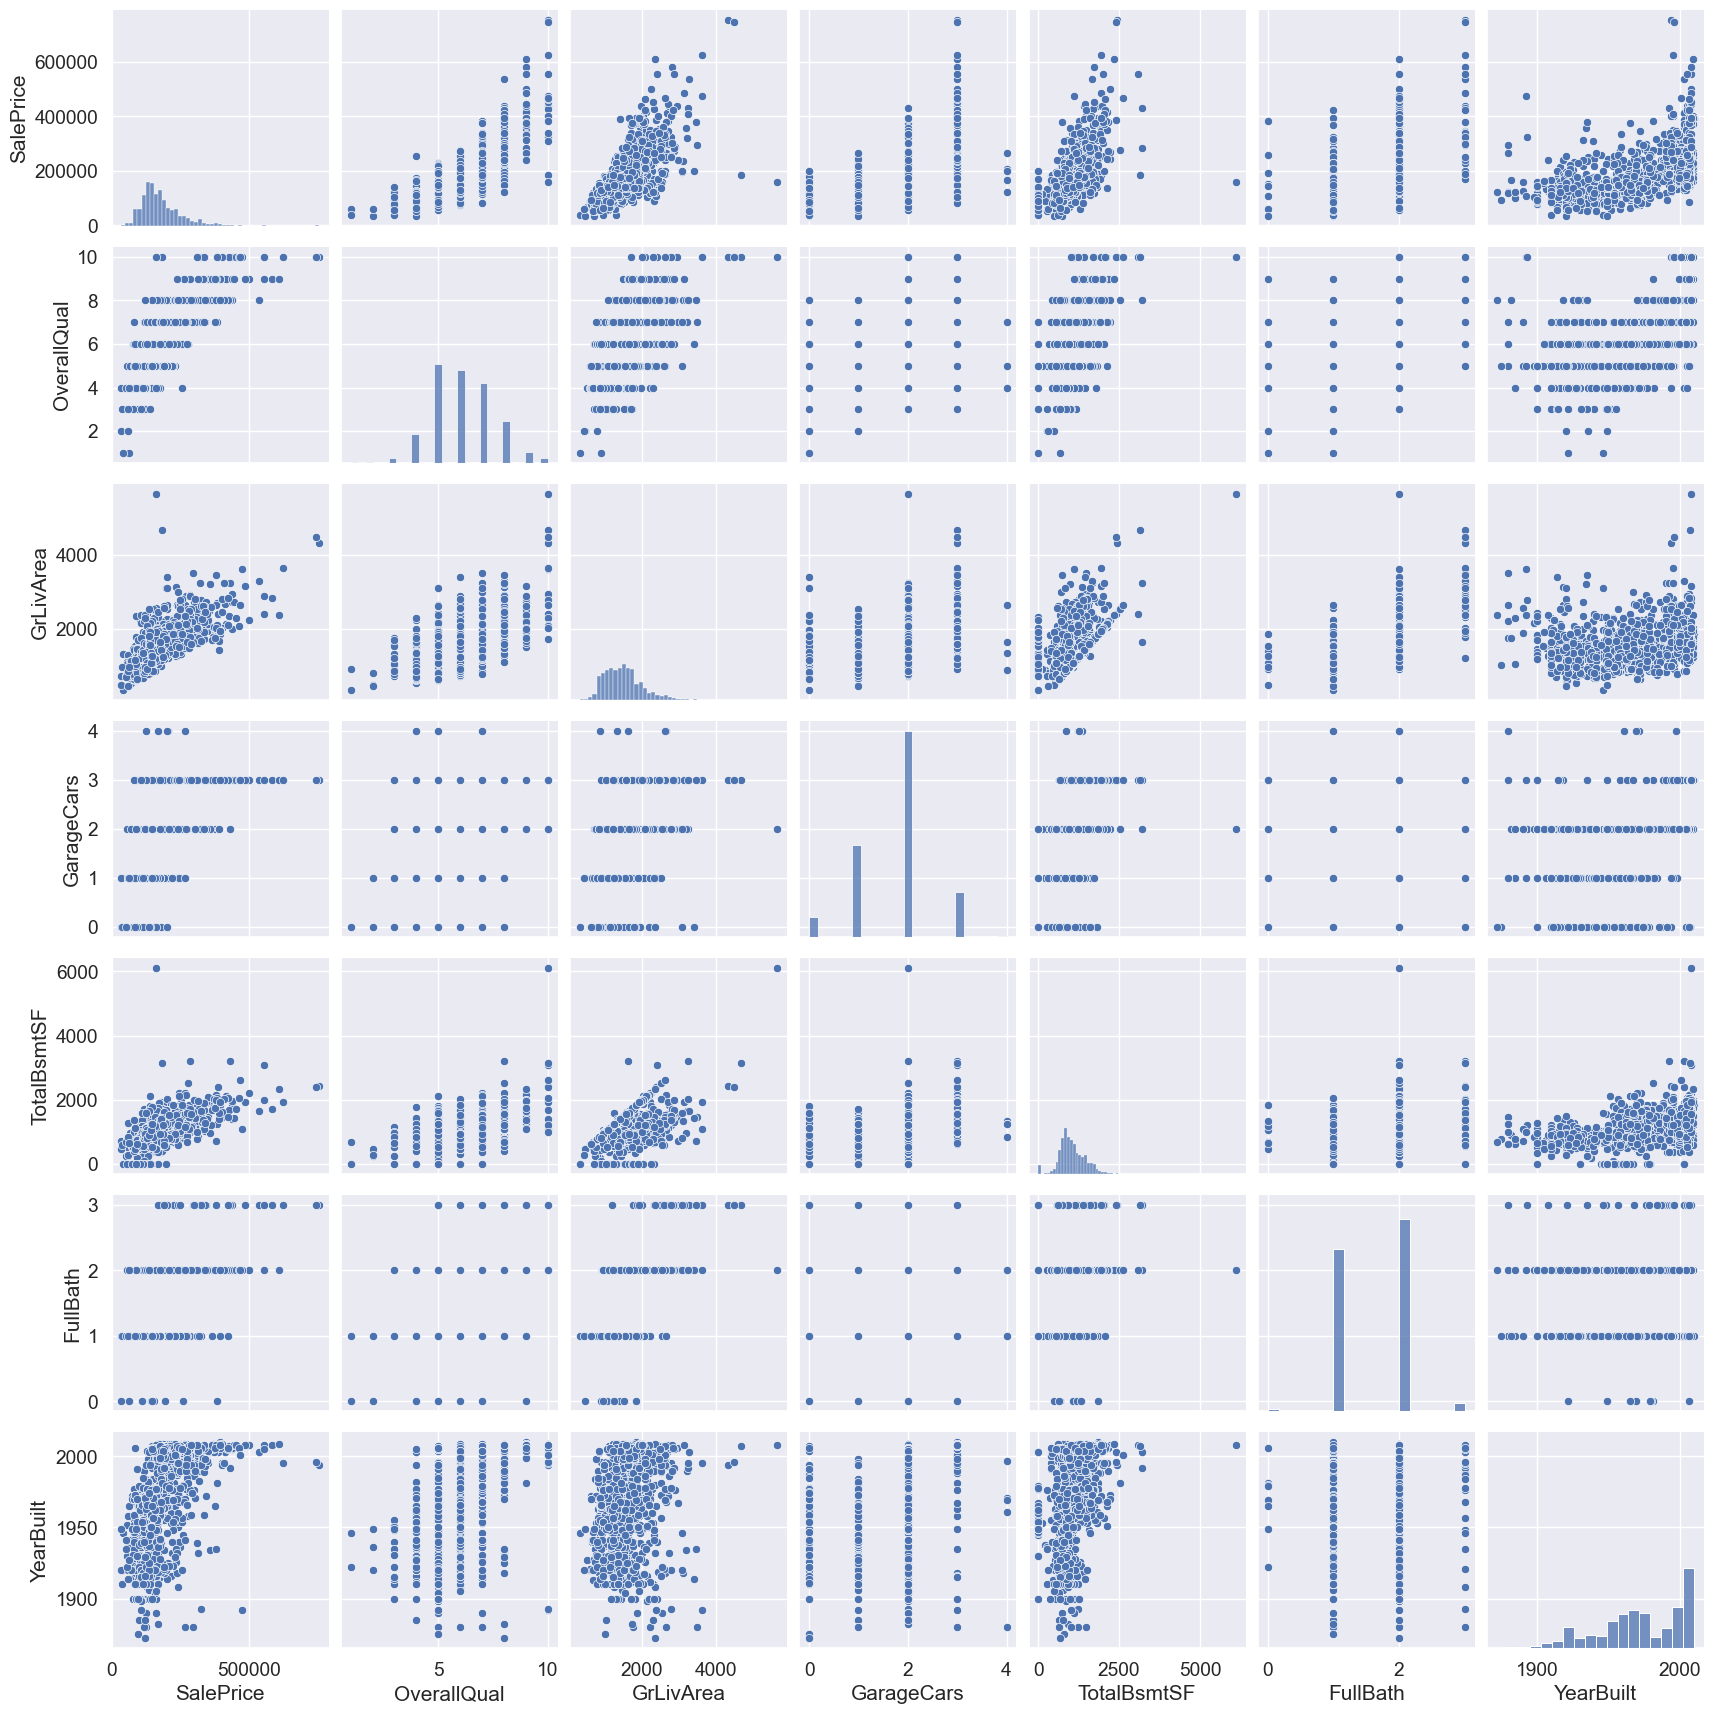

In [54]:
var_set = ['SalePrice', 'OverallQual', 'GrLivArea',
'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sb.set (font_scale = 1.25) # Устанавливаем размер шрифта по горизонтальной и вертикальной оси
sb.pairplot (df[var_set]) # 7 * 7 графическая матрица
# Различные типы отображения могут быть установлены в
# параметрах kind и diag_kind, вот диаграммы разброса и
# гистограммы, и вы также можете установить разные типы 
# отображения на каждом графике
plt.show()